# Initial Imports and Constants

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from lightkurve import search_targetpixelfile
import pandas as pd
import os
import batman
from scipy.stats import norm
import matplotlib
import os

In [59]:
### Define data directory
working_dir = os.getcwd()
data_dir = os.path.join(working_dir, "data")
print(f"Data directory: {data_dir}")

Data directory: /Users/pentrican10/Projects/tess-resonant-systems/data


In [60]:
### switch to mask out transits
mask_transits = True
### set range for search: [#hours] * [days per hour]
ttv_hour = 4* 0.0416667 # 1 hour to days

In [61]:
### function to convert times from TESS to Petigura offset
TESS_offset = 2457000
petigura_offset = 2454833
def convert_time_t2p(times):
    ### TESS offset 
    BTJD = times + TESS_offset
    new_time = BTJD - petigura_offset
    return new_time

# Get data

In [62]:
TOI_id = 'TOI 4495'
search_result = lk.search_lightcurve(TOI_id, author='SPOC', exptime=120)
print(search_result)
# lc_collection = search_result.download_all()
# lc = lc_collection
# lc[0].download()
# lc[1].download()
# lc[2].download()
# lc[3].download()


# lc_collection = lc[0].download()
# lc_collection.append(lc[1].download())
# lc_collection.append(lc[3].download())

SearchResult containing 7 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 14 2019   SPOC     120   120826158      0.0
  1 TESS Sector 40 2021   SPOC     120   120826158      0.0
  2 TESS Sector 41 2021   SPOC     120   120826158      0.0
  3 TESS Sector 53 2022   SPOC     120   120826158      0.0
  4 TESS Sector 54 2022   SPOC     120   120826158      0.0
  5 TESS Sector 80 2024   SPOC     120   120826158      0.0
  6 TESS Sector 81 2024   SPOC     120   120826158      0.0


In [63]:
lc_collection = search_result.download_all()
# lc_collection.plot()
# plt.show()
print(lc_collection)

LightCurveCollection of 7 objects:
    0: <TessLightCurve LABEL="TIC 120826158" SECTOR=14 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    1: <TessLightCurve LABEL="TIC 120826158" SECTOR=40 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    2: <TessLightCurve LABEL="TIC 120826158" SECTOR=41 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    3: <TessLightCurve LABEL="TIC 120826158" SECTOR=53 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    4: <TessLightCurve LABEL="TIC 120826158" SECTOR=54 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    5: <TessLightCurve LABEL="TIC 120826158" SECTOR=80 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
    6: <TessLightCurve LABEL="TIC 120826158" SECTOR=81 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>


In [64]:
clean_lcs = [lc[lc.quality == 0] for lc in lc_collection]


In [65]:
# Normalize, flatten, and remove outliers
processed_lcs = [
    lc.normalize().flatten(window_length=401).remove_outliers(sigma=5)
    for lc in clean_lcs
]

In [66]:
# Stitch into one combined light curve
combined_lc = processed_lcs[0]
for lc in processed_lcs[1:]:
    combined_lc = combined_lc.append(lc)



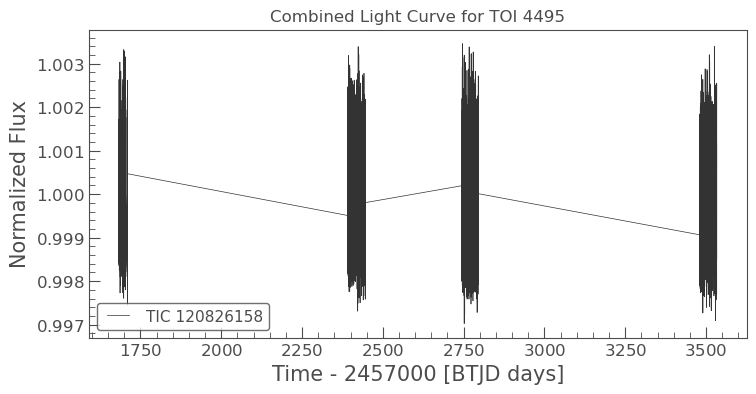

In [67]:
combined_lc.plot()
plt.title(f"Combined Light Curve for {TOI_id}")
plt.show()

In [68]:
# Extract useful data arrays
time = combined_lc.time.value
flux = combined_lc.flux.value
flux_err = combined_lc.flux_err.value
print(time)
print(flux)

[1683.35690317 1683.35829206 1683.35968094 ... 3533.17624718 3533.17763605
 3533.17902491]
[1.00110702 0.9993466  1.00023161 ... 1.0025522  1.00050692 1.0011754 ]


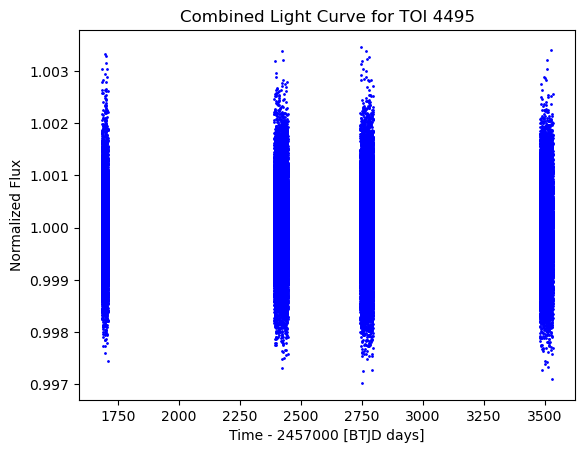

In [69]:
plt.scatter(time, flux, s=1, c='b')
plt.title(f'Combined Light Curve for {TOI_id}')
plt.xlabel('Time - 2457000 [BTJD days]')
plt.ylabel('Normalized Flux')
plt.show()

# BLS Runs

## BLS 1

`period` contains 119764 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


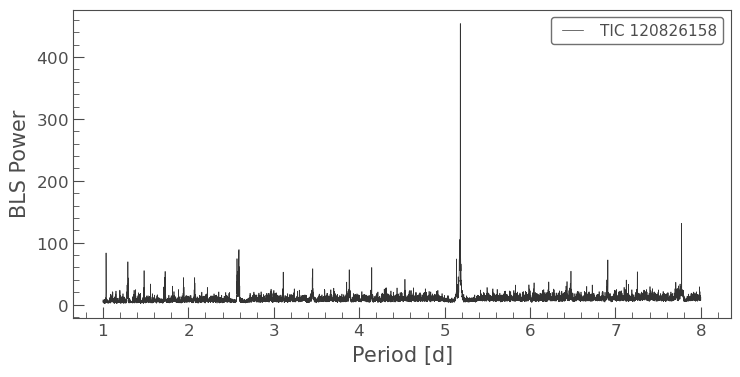

In [70]:
bls_1 = combined_lc.to_periodogram(method='bls', period=np.linspace(1, 8, 10000), frequency_factor=500)
bls_1.plot()
plt.show()


In [71]:
planet_1_period = bls_1.period_at_max_power
planet_1_dur = bls_1.duration_at_max_power
planet_1_t0 = bls_1.transit_time_at_max_power

print(f"Best candidate period: {planet_1_period.value:.5f} days")
print(f"Best candidate t0: {planet_1_t0.value:.5f} days")
print(f"Best candidate dur: {planet_1_dur.value:.5f} days")

Best candidate period: 5.18362 days
Best candidate t0: 1687.74690 days
Best candidate dur: 0.10000 days


In [72]:
import numpy as np
from scipy.signal import find_peaks

# 1. Access full power array
powers = bls_1.power.value
periods = bls_1.period.value
durations = bls_1.duration.value
t0s = bls_1.transit_time.value

# 2. Find all peaks in the BLS power spectrum
peaks, _ = find_peaks(powers)

# 3. Sort peaks by power (descending)
sorted_peaks = peaks[np.argsort(powers[peaks])[::-1]]

# 4. Get top 3 signal indices
top_indices = sorted_peaks[:7]

# 5. Extract their periods, durations, and t0s
top_periods = periods[top_indices]
top_durations = durations[top_indices]
top_t0s = t0s[top_indices]
top_powers = powers[top_indices]

# 6. Print results
for i in range(7):
    print(f"Signal {i+1}:")
    print(f"  Period:   {top_periods[i]:.5f} days")
    print(f"  T0:       {top_t0s[i]:.5f}")
    print(f"  Duration: {top_durations[i]:.5f} days")
    print(f"  Power:    {top_powers[i]:.5f}")
    print("-" * 30)


Signal 1:
  Period:   5.18362 days
  T0:       1687.74690
  Duration: 0.10000 days
  Power:    454.02216
------------------------------
Signal 2:
  Period:   7.77528 days
  T0:       1690.35690
  Duration: 0.10000 days
  Power:    131.19417
------------------------------
Signal 3:
  Period:   5.17732 days
  T0:       1683.47690
  Duration: 0.10000 days
  Power:    104.97431
------------------------------
Signal 4:
  Period:   5.17872 days
  T0:       1688.46190
  Duration: 0.10000 days
  Power:    103.63639
------------------------------
Signal 5:
  Period:   5.18642 days
  T0:       1687.37190
  Duration: 0.10000 days
  Power:    89.38603
------------------------------
Signal 6:
  Period:   2.59196 days
  T0:       1685.09190
  Duration: 0.15000 days
  Power:    88.84822
------------------------------
Signal 7:
  Period:   2.58566 days
  T0:       1684.31690
  Duration: 0.10000 days
  Power:    86.56527
------------------------------


In [73]:
# Create a cadence mask using the BLS parameters
planet_1_mask = bls_1.get_transit_mask(period=planet_1_period,
                                     transit_time=planet_1_t0,
                                     duration=planet_1_dur*1.5)

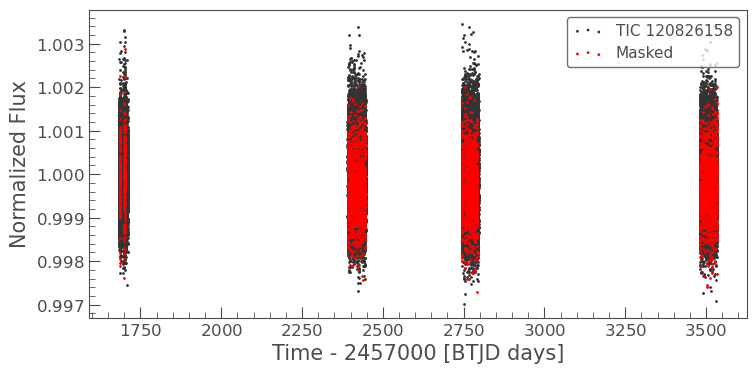

In [74]:
masked_lc_1 = combined_lc[~planet_1_mask]
ax = masked_lc_1.scatter();
combined_lc[planet_1_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [75]:
# Create a BLS model using the BLS parameters
planet_1_model = bls_1.get_transit_model(period=planet_1_period,
                                       transit_time=planet_1_t0,
                                       duration=planet_1_dur)


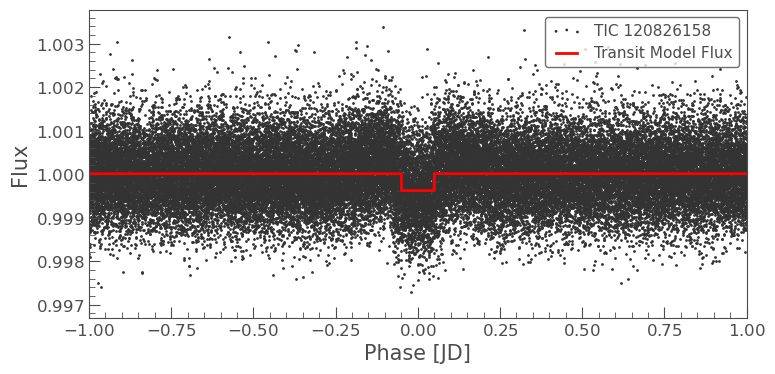

In [76]:
ax = combined_lc.fold(planet_1_period, planet_1_t0).scatter()
planet_1_model.fold(planet_1_period, planet_1_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## BLS 2

`period` contains 119746 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


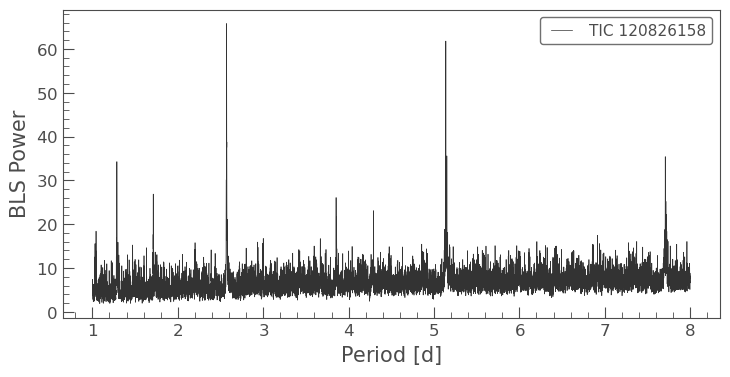

In [77]:
period = np.linspace(1, 8, 10000)
bls_2 = masked_lc_1.to_periodogram('bls', period=period, frequency_factor=500)
bls_2.plot()
plt.show()

In [78]:
planet_2_period = bls_2.period_at_max_power
planet_2_t0 = bls_2.transit_time_at_max_power
planet_2_dur = bls_2.duration_at_max_power

print(f"Best candidate period 2: {planet_2_period.value:.5f} days")
print(f"Best candidate t0 2: {planet_2_t0.value:.5f} days")

Best candidate period 2: 2.56956 days
Best candidate t0 2: 1685.68690 days


In [79]:
# ax = masked_lc_1.fold(planet_2_period, planet_2_t0).scatter()
# masked_lc_1.fold(planet_2_period, planet_2_t0).bin(.1).plot(ax=ax, c='r', lw=2,
#                                                           label='Binned Flux')
# ax.set_xlim(-5, 5)
# plt.show()

In [80]:
planet_2_mask = bls_2.get_transit_mask(period=planet_2_period,
                                     transit_time=planet_2_t0,
                                     duration=planet_2_dur*1.5)

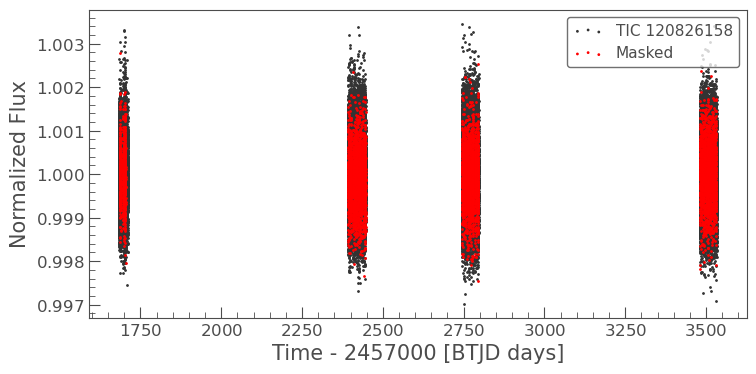

In [81]:
masked_lc_2 = masked_lc_1[~planet_2_mask]
ax = masked_lc_2.scatter();
masked_lc_1[planet_2_mask].scatter(ax=ax, c='r', label='Masked')
# plt.xlim(2144, 2145)
plt.show()

In [82]:
planet_2_model = bls_2.get_transit_model(period=planet_2_period,
                                       transit_time=planet_2_t0,
                                       duration=planet_2_dur)

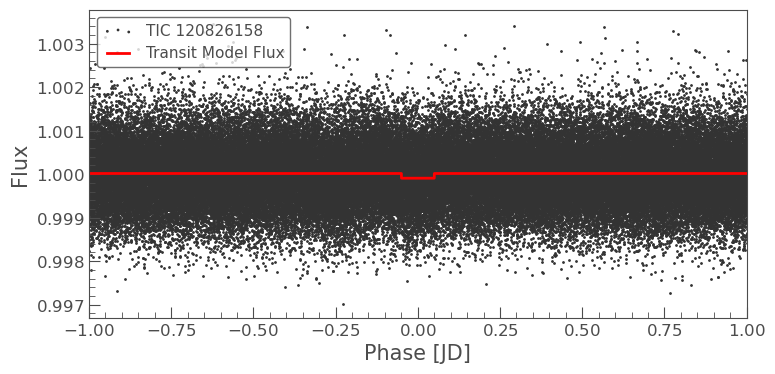

In [83]:
ax = combined_lc.fold(planet_2_period, planet_2_t0).scatter()
planet_2_model.fold(planet_2_period, planet_2_t0).plot(ax=ax, c='r', lw=2)
ax.set_xlim(-1, 1)
plt.show()

## Transit models

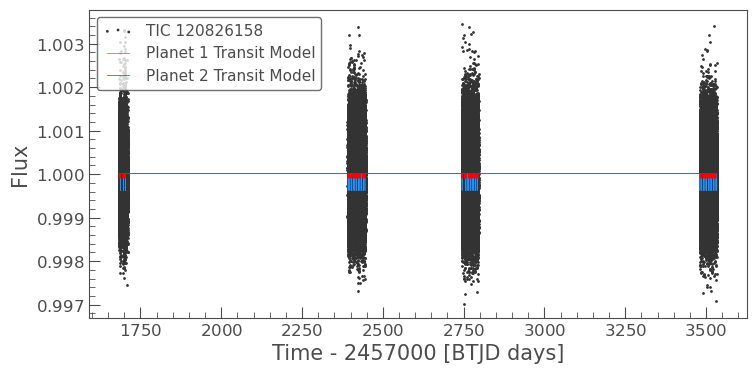

In [84]:
ax = combined_lc.scatter();
planet_1_model.plot(ax=ax, c='dodgerblue', label='Planet 1 Transit Model');
planet_2_model.plot(ax=ax, c='r', label='Planet 2 Transit Model');
# planet_3_model.plot(ax=ax, c='g', label='Planet 3 Transit Model');
# planet_4_model.plot(ax=ax, c='purple', label='Planet 4 Transit Model');
# planet_5_model.plot(ax=ax, c='orange', label='Planet 5? Transit Model');
# planet_6_model.plot(ax=ax, c='pink', label='Planet 6 Transit Model');

# plt.xlim(1340,1345)
# plt.ylim(0.998,1.002)
plt.show()

## Finding transit guess times based on models 

In [85]:
from scipy.signal import find_peaks

# Find all local minima (i.e., transit dips)
peaks_1, _ = find_peaks(-planet_1_model.flux.value, prominence=1e-5)
transit_times_1 = planet_1_model.time.value[peaks_1]
fluxes_1 = planet_1_model.flux.value[peaks_1]

print("Planet 1 transit dip times and depths:")
# for t, f in zip(transit_times_1, fluxes_1):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_1)

Planet 1 transit dip times and depths:
[1687.74577004 1698.11513541 1703.29699077 2392.71889577 2397.90230147
 2403.08570072 2408.26906189 2413.45240328 2418.63573764 2423.82041329
 2429.00369064 2434.18695288 2439.37156246 2444.5547795  2745.20595862
 2755.57147659 2760.75489038 2765.93829095 2771.12306947 2776.3064155
 2781.48975676 2786.67306003 2791.85634522 3481.27755702 3486.43459958
 3491.64580156 3496.82920173 3502.01257124 3507.19593455 3512.37925708
 3517.56395345 3522.74724368 3527.93049878 3533.11374829]


In [86]:
# Find all local minima (i.e., transit dips)
peaks_2, _ = find_peaks(-planet_2_model.flux.value, prominence=1e-5)
transit_times_2 = planet_2_model.time.value[peaks_2]
fluxes_2 = planet_2_model.flux.value[peaks_2]

print("Planet 2 transit dip times and depths:")
# for t, f in zip(transit_times_2, fluxes_2):
#     print(f"Time: {t:.5f}, Flux: {f:.6f}")
print(transit_times_2)

Planet 2 transit dip times and depths:
[1685.68605881 1688.24993383 1695.96377334 1698.53457287 1701.10397371
 1703.67476179 2392.31472332 2394.88420444 2397.45368435 2400.02316244
 2402.59263906 2407.73156069 2410.3010104  2412.87045833 2415.4399043
 2418.00934905 2420.58016799 2423.14958673 2425.7190047  2428.28842099
 2430.85783587 2435.99663583 2438.56602456 2441.13541225 2443.70618764
 2446.27557375 2744.34343866 2746.91294271 2752.05195141 2754.62145479
 2757.19095386 2759.76043263 2764.90077788 2767.47025449 2770.03973286
 2772.60918435 2775.17863524 2777.74808491 2780.31753315 2785.45640417
 2788.0258257  2790.5952463  2793.16466561 2795.73547261 3481.80673482
 3484.376229   3486.94571973 3492.08469823 3494.6541812  3497.2236494
 3499.7931127  3502.36257335 3504.93203322 3507.50149078 3510.07232097
 3512.64175595 3515.21118798 3517.7597858  3520.35004943 3522.91946356
 3525.48887064 3528.05827449 3530.62767693]


In [87]:
# # Find all local minima (i.e., transit dips)
# peaks_3, _ = find_peaks(-planet_3_model.flux.value, prominence=1e-5)
# transit_times_3 = planet_3_model.time.value[peaks_3]
# fluxes_3 = planet_3_model.flux.value[peaks_3]

# print("Planet 3 transit dip times and depths:")
# # for t, f in zip(transit_times_2, fluxes_2):
# #     print(f"Time: {t:.5f}, Flux: {f:.6f}")
# print(transit_times_3)

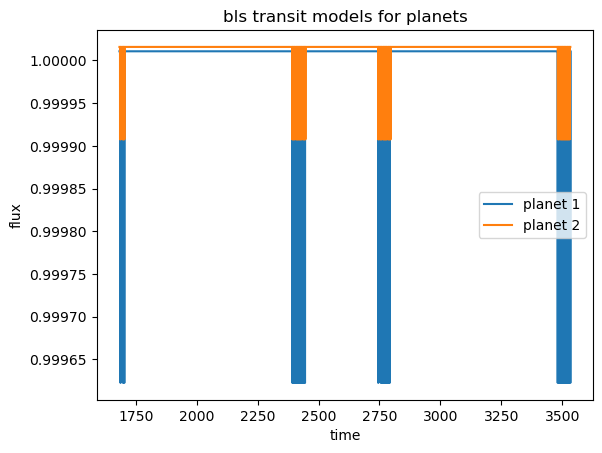

In [88]:
plt.plot(planet_1_model.time.value, planet_1_model.flux.value, label='planet 1')
plt.plot(planet_2_model.time.value, planet_2_model.flux.value, label='planet 2')
# plt.plot(planet_3_model.time.value, planet_3_model.flux.value, label='planet 3')
# plt.plot(planet_4_model.time.value, planet_4_model.flux.value, label='planet 4')
# plt.plot(planet_5_model.time.value, planet_5_model.flux.value, label='planet 5?')
# plt.plot(planet_6_model.time.value, planet_6_model.flux.value, label='planet 6?')

# plt.xlim(1335,1345)
# plt.xlim(1330,1350)
# plt.xlim(2100,2200)
# plt.xlim(1377,1380)
plt.title('bls transit models for planets')
plt.xlabel('time')
plt.ylabel('flux')
plt.legend()
plt.show()

# Fit Transit Times

In [89]:
from scipy.optimize import minimize
from scipy.optimize import root_scalar
from scipy.optimize import least_squares
from scipy.optimize import curve_fit

## Definitions

In [90]:
def omc(obs_time, t_num, p, tc):
    calc_time = tc + (t_num* p)
    omc = obs_time - calc_time
    return omc#*24 #days to hours

### Find the intersection points
def intersection_func(t,tc1,chi_sq, err_threshold): 
    return np.interp(t, tc1, chi_sq) - err_threshold

In [91]:

def plot_chi_sq(time, flux, flux_err, tc, tc_guess, per, rp, b, T14, u1, u2):
    '''
    args:
        time: array of times from lightcurve
        flux: array of fluxes from lightcurve
        flux_err: array of flux errors from lightcurve
        tc: range of values around the guess time
        tc_guess: guess transit time
        per: period of planet
        rp: radius ratio (planet/star)
        b: impact parameter
        T14: transit duration
        u1, u2: limb darkening coefficients 
    '''
    ### plot X^2 vs tc for each guess
    for j in range(len(tc)):
        tc1 = tc[j]
        chi_sq = np.zeros(len(tc1))
        chi_sq_lc = np.zeros(len(tc1))
        for i in range(len(tc1)):
            t0_1 = 	tc1[i]
            theta_initial = [t0_1, per, rp, b, T14, u1, u2]
            
            ### initialize params
            params = batman.TransitParams()
            # params.t0, params.per, params.rp,params.b, params.T14, q1, q2 = theta_initial
            # params.u = [2*np.sqrt(q1)*q2, np.sqrt(q1)*(1-2*q2)]  # Limb darkening coefficients
            params.t0, params.per, params.rp,params.b, params.T14, u1, u2 = theta_initial
            params.u = [u1, u2] 
            params.limb_dark = 'quadratic'
            
            ### mask data - extract relevant photometry
            start = tc_guess[j] - ttv_hour
            end = tc_guess[j] + ttv_hour
            mask = (time > (start)) & (time < (end))
            
            transit_model = batman.TransitModel(params, time[mask])
                
            # Generate model light curve
            model_flux = transit_model.light_curve(params)
            
            # Calculate chi-squared value
            sigma2 = flux_err[mask] 
            chi_squared = np.sum(((flux[mask] - model_flux) / sigma2)**2)
            chi_sq[i] = (chi_squared)
    
        ### masked
        min_chi_time = tc1[np.argmin(chi_sq)]
        min_chi = chi_sq.min()
    
        tc_chi[j] = min_chi_time
        # idx = transit_num[j]
        ttv[j] = min_chi_time - tc_guess[j]
    
        chi_mask = (chi_sq <= min_chi + 3)
        fit_mask = (chi_sq <= min_chi + 1)
    
        ### fit parabola to the chisq
        p_chi_sq = np.polyfit(tc1[fit_mask], chi_sq[fit_mask], 2)  
    
        ### Extract the coefficients   y = ax^2 + bx + c
        a_chi_sq, b_chi_sq, c_chi_sq = p_chi_sq
        
        ### Find the minimum of the parabola xmin = -b/2a from taking derivative=0
        tc_best_fit = -b_chi_sq / (2 * a_chi_sq)
        
        ### Calculate the minimum chi-squared value
        chi_sq_min = a_chi_sq * tc_best_fit**2 + b_chi_sq * tc_best_fit + c_chi_sq
        tc_chi_parabola[j] = tc_best_fit
    
        ### Calculate the parabola best fit 
        p_1 = a_chi_sq*tc1**2 + b_chi_sq*tc1 + c_chi_sq
    
        ### calculate ttv from parabola fit 
        ttv_p[j] = tc_best_fit - tc_guess[j]
    
        ### delta chisq = 1 gives errors
        err_threshold = min_chi + 1 # using chisq discrete minimum
        err_threshold_p = chi_sq_min + 1 # using minimum of parabola
      
        # # Find the intersection using root_scalar
        # intersections = []
        # for k in range(len(tc1) - 1):
        #     if (chi_sq[k] - err_threshold) * (chi_sq[k + 1] - err_threshold) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections.append((sol.root - min_chi_time))
        # errors.append(intersections)
    
        # intersections_p = []
        # for k in range(len(tc1) - 1):
        #     if (p_1[k] - err_threshold_p) * (p_1[k + 1] - err_threshold_p) < 0:
        #         sol = root_scalar(intersection_func, bracket=[tc1[k], tc1[k + 1]], args=(tc1, chi_sq, err_threshold))
        #         if sol.converged:
        #             intersections_p.append((sol.root - tc_best_fit))
        # errors_p.append(intersections_p)
    
        # plt.plot(tc1[chi_mask], chi_sq[chi_mask],label='chisq')
        # plt.plot(tc1[chi_mask], p_1[chi_mask],label='chisq parabola', color='orange')
        # plt.axvline(x=tc_guess[j], color='r', linestyle='--', label='Bls Guess')
        # plt.axvline(x=min_chi_time, linestyle='--', label='Chisq min')
        # plt.axvline(x=tc1[np.argmin(p_1)], color='orange', linestyle='--', label='Chisq min parabola')
    
        # # for inter in intersections:
        # #     plt.axvline(x=inter, color='blue', linestyle='--')
        # plt.axhline(y=err_threshold, color='green', linestyle='--', label='Error Threshold')
        # plt.title(f'Transit {j+1}: Planet b')
        # plt.xlabel('tc')
        # plt.ylabel('X^2')
        # plt.legend()
        # plt.show()

    return tc_chi, ttv

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import batman

def plot_transits(transit_times, per, rp, b, T14, u1, u2):
    cols = 3
    rows = int(np.ceil(len(transit_times) / cols))
    
    fig = plt.figure(figsize=(14, rows * 2.8))
    outer = gridspec.GridSpec(rows, cols, figure=fig, wspace=0.3, hspace=0.5)
    
    for i, t0 in enumerate(transit_times):
        row = i // cols
        col = i % cols
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[row, col],
                                                 height_ratios=[3, 1], hspace=0.0)  # Panels touch
    
        t_min = t0 - buffer
        t_max = t0 + buffer
        mask = (time >= t_min) & (time <= t_max)
        time_rel = time[mask] - t0  # Time relative to Tc
    
        # Transit model setup
        theta_initial = [t0, per, rp, b, T14, u1, u2]
        params = batman.TransitParams()
        params.t0, params.per, params.rp, params.b, params.T14, u1, u2 = theta_initial
        params.u = [u1, u2]
        params.limb_dark = 'quadratic'
    
        m = batman.TransitModel(params, time[mask])
        model_flux = m.light_curve(params)
        residuals = flux[mask] - model_flux

        # Calculate binned points
        num_bins = 20  # Adjust number of bins as needed
        bins = np.linspace(-buffer, buffer, num_bins + 1)
        digitized = np.digitize(time_rel, bins)
        bin_means = [flux[mask][digitized == i].mean() for i in range(1, len(bins))]
        bin_centers = 0.5 * (bins[1:] + bins[:-1])
    
    
        # Top panel: model + data
        ax1 = fig.add_subplot(inner[0])
        ax1.scatter(time_rel, flux[mask], s=5, label='Data')
        ax1.scatter(bin_centers, bin_means, c='orange', marker='o', label='Binned Data')
        ax1.plot(time_rel, model_flux, color='red', label='Model')
        ax1.axvline(0, color='green', linestyle='--', label='Tc')
        ax1.set_xlim(-buffer, buffer)
        ax1.set_title(f'Tc = {round(t0, 3)} (BJD-{TESS_offset})')
        ax1.grid(True)
        ax1.tick_params(labelbottom=False)
    
        # Bottom panel: residuals
        ax2 = fig.add_subplot(inner[1], sharex=ax1)
        ax2.scatter(time_rel, residuals, s=5)
        ax2.scatter(bin_centers, [0] * len(bin_centers), c='orange', marker='o', label='Binned Data')
        ax2.axhline(0, color='red', linestyle='--', linewidth=1)
        ax2.set_xlim(-buffer, buffer)
        ax2.set_xlabel("Time from Tc [days]")
        ax2.grid(True)
    
        # Y-axis labels for first column only
        if col == 0:
            ax1.set_ylabel("Flux")
            ax2.set_ylabel("Residuals")
        else:
            ax1.set_ylabel("")
            ax1.tick_params(labelleft=False)
            ax2.set_ylabel("")
            ax2.tick_params(labelleft=False)
    
        # Custom ticks
        ticks = np.round(np.linspace(-buffer, buffer, 4), 2)
        ax2.set_xticks(ticks)
    
    plt.show()


In [93]:
def plot_folded_from_transits(transit_times, time, flux, per, rp, b, T14, u1, u2, buffer=0.1, num_bins=50, title=None, TESS_offset=2457000):
    """
    Fold and plot multiple transits using the list of observed transit_times (not just period).
    
    Parameters:
        transit_times (array): List of observed mid-transit times (Tc).
        time (array): Time array (BJD).
        flux (array): Normalized flux array.
        per (float): Period (used only for model shape).
        rp (float): Planet/star radius ratio.
        b (float): Impact parameter.
        T14 (float): Total transit duration.
        u1, u2 (float): Quadratic limb darkening coefficients.
        buffer (float): Time window around each transit center (days).
        num_bins (int): Number of bins for binned light curve.
        TESS_offset (float): Offset subtracted from BJD for labels.
    """
    
    all_phase = []
    all_flux = []

    for t0 in transit_times:
        mask = (time >= t0 - buffer) & (time <= t0 + buffer)
        if np.sum(mask) == 0:
            continue
        phase = time[mask] - t0  # center on each Tc
        all_phase.append(phase)
        all_flux.append(flux[mask])

    # Concatenate all extracted windows
    folded_phase = np.concatenate(all_phase)
    # folded_phase=np.sort(folded_phase)
    folded_flux = np.concatenate(all_flux)

    # Build transit model centered at phase=0
    params = batman.TransitParams()
    params.t0 = 0
    params.per = per
    params.rp = rp
    params.b = b
    params.T14 = T14
    params.u = [u1, u2]
    params.limb_dark = 'quadratic'

    m = batman.TransitModel(params, folded_phase)
    model_flux = m.light_curve(params)
    residuals = folded_flux - model_flux

    # Bin data
    bins = np.linspace(-buffer, buffer, num_bins + 1)
    bin_indices = np.digitize(folded_phase, bins)
    bin_centers = 0.5 * (bins[1:] + bins[:-1])
    bin_means = [folded_flux[bin_indices == i].mean() if np.any(bin_indices == i) else np.nan for i in range(1, len(bins))]

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, height_ratios=[3, 1])

    ax1.scatter(folded_phase, folded_flux, s=5, alpha=0.6, label='Data')
    ax1.plot(folded_phase, model_flux, color='red', label='Model')
    ax1.scatter(bin_centers, bin_means, color='orange', label='Binned', zorder=3)
    ax1.axvline(0, color='green', linestyle='--', label='Tc')
    ax1.set_ylabel("Flux")
    if title==None:
        ax1.set_title(f"Folded Transit from {len(transit_times)} Events")
    else:
        ax1.set_title(title)

    ax1.grid(True)
    ax1.legend()

    ax2.scatter(folded_phase, residuals, s=5)
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel("Time from Tc [days]")
    ax2.set_ylabel("Residuals")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [94]:
### stellar params
# q1 = 0.329
# q2 = 0.249

# u1 = 2 * np.sqrt(q1) * q2
# u2 = np.sqrt(q1) * (1 - 2 * q2)

u1 = 0.21
u2 = 0.38
print(u1)
print(u2)

0.21
0.38


## Planet 1

In [95]:
### Planet params 
# NO DATA
import astropy.constants as u

per_1=  5.1830043
rp_1=   (3.63045*u.R_earth.value) /   (1.34*u.R_sun.value)
b_1=  0.336
T14_1= 2.783* 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [96]:
tc_guess_1 = transit_times_1
### get tc ranges for fit
tc_1 = []
for i in range(len(tc_guess_1)):
    start = tc_guess_1[i] - ttv_hour
    end = tc_guess_1[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_1.append(t)

In [97]:
### initialize arrays
tc_chi = np.zeros(len(tc_1))
tc_chi_parabola = np.zeros(len(tc_1))
ttv = np.zeros(len(tc_1))
ttv_p = np.zeros(len(tc_1))
errors = []
errors_p = []

In [98]:
tc_chi_1, ttv_1 = plot_chi_sq(time, flux, flux_err, tc_1, tc_guess_1, per_1, rp_1, b_1, T14_1, u1, u2)

In [99]:
print(tc_chi_1)

[1687.82968736 1698.2033904  1703.40159546 2392.74775799 2397.94150738
 2403.11923428 2408.29125076 2413.47626049 2418.66660187 2423.82758714
 2429.02521218 2434.19379306 2439.3717293  2444.56262068 2745.18577175
 2755.5616334  2760.74571453 2765.93412011 2771.09954593 2776.304914
 2781.4775779  2786.65587617 2791.8498387  3481.26771384 3486.4604588
 3491.6306197  3496.81335253 3501.99405271 3507.17975169 3512.36674455
 3517.54343292 3522.71571212 3527.90297123 3533.09122575]


In [100]:
# Transit windows
buffer = 1.5 * T14_1
transit_times_1 = tc_chi_1

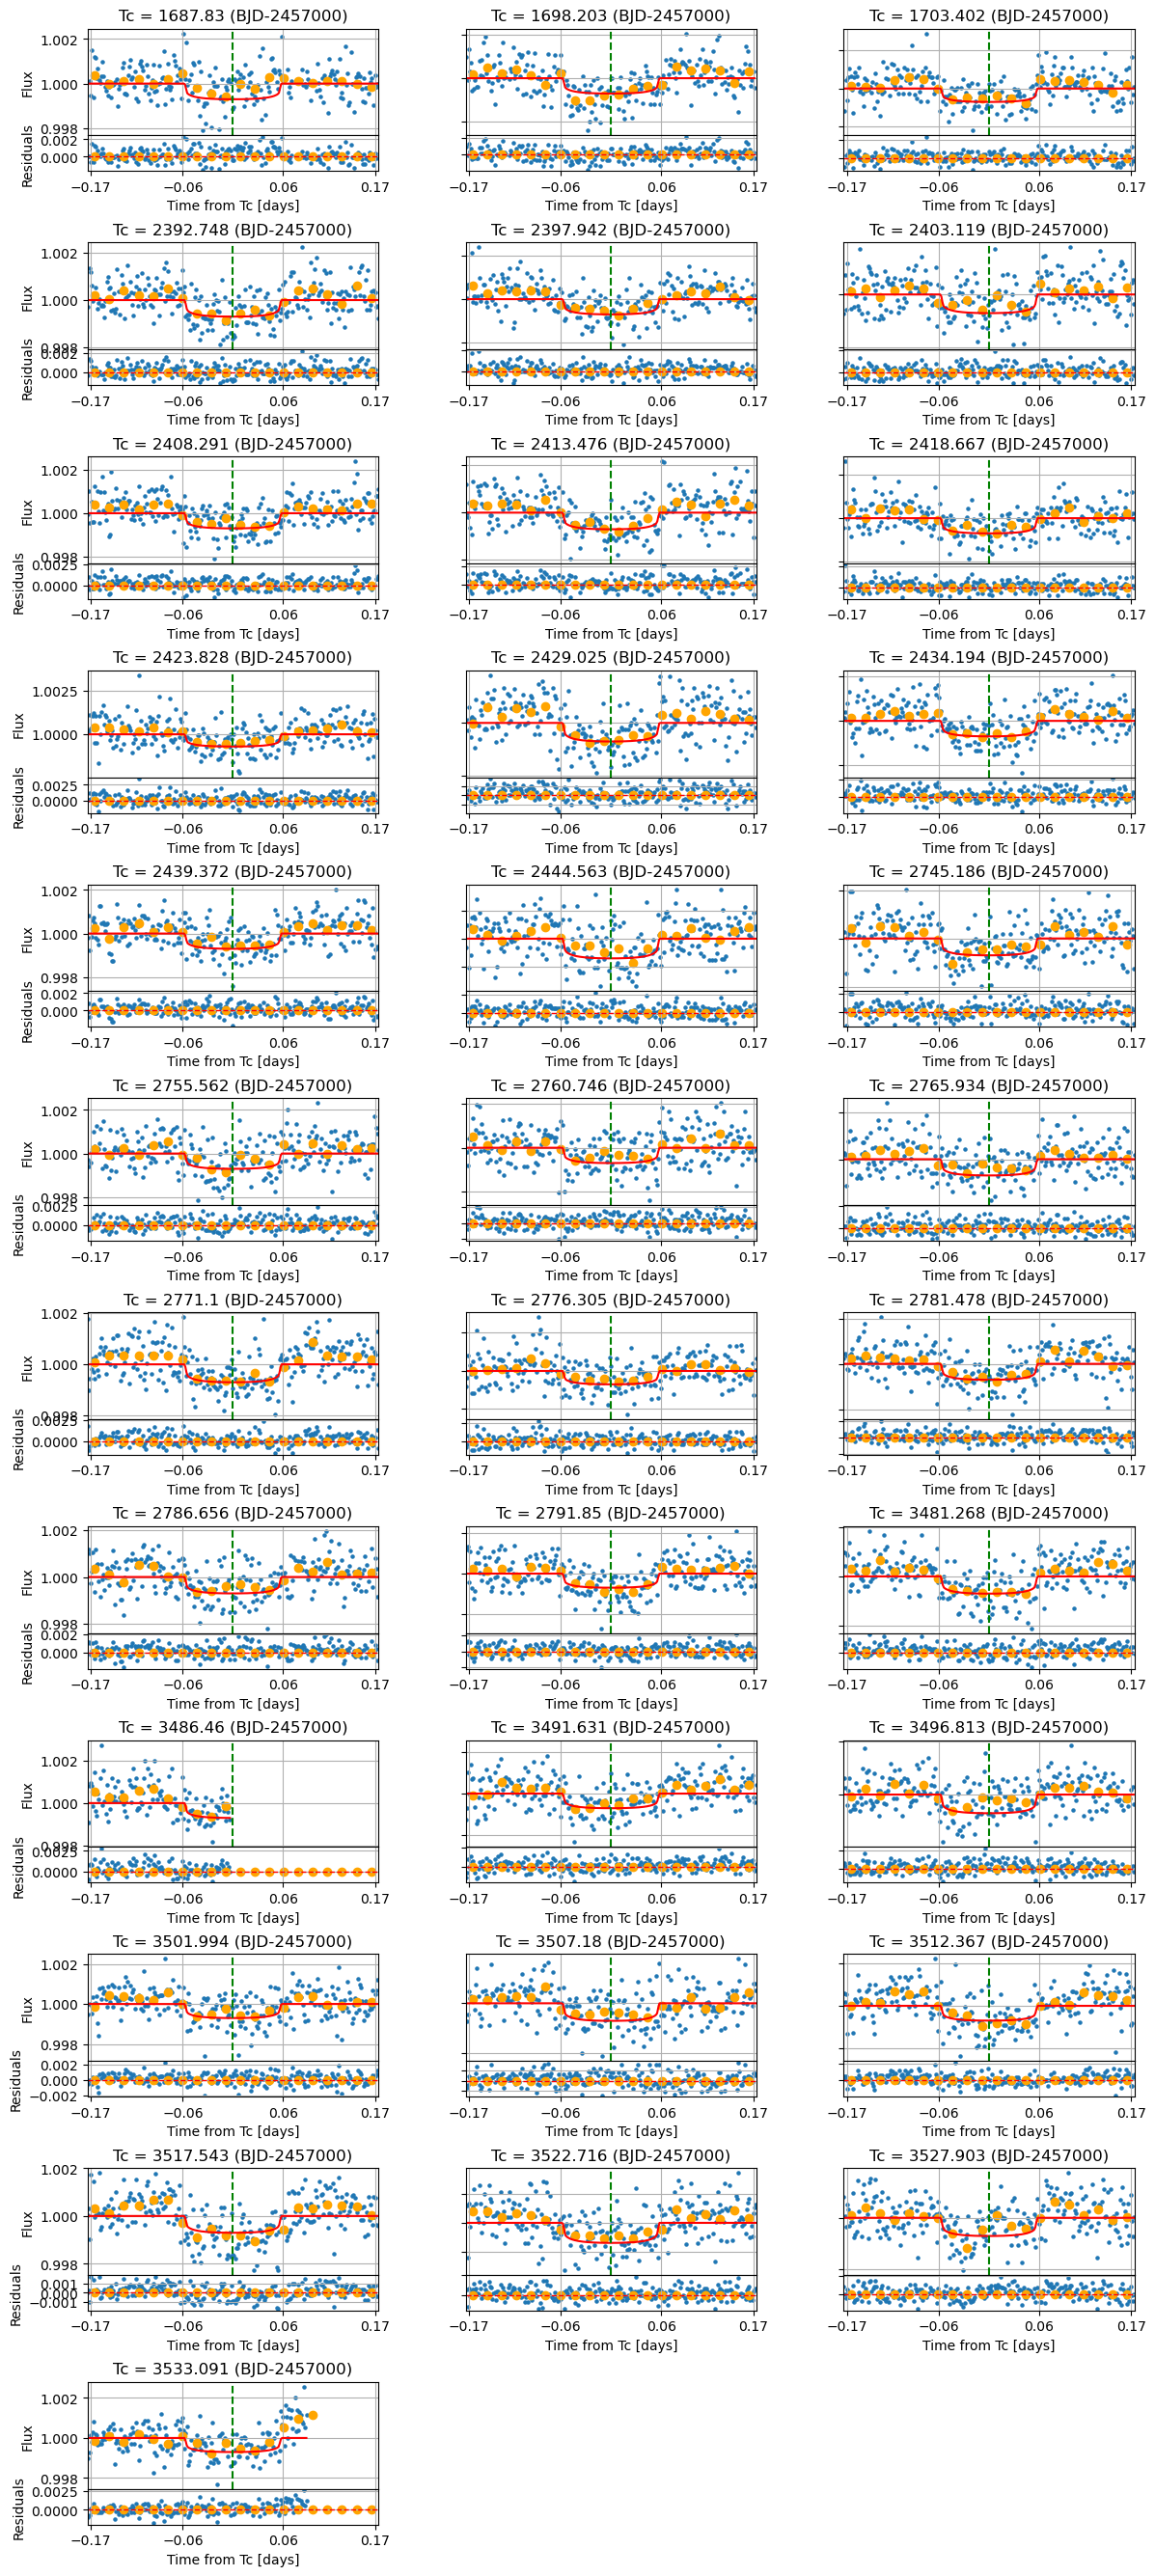

In [101]:
plot_transits(transit_times_1, per_1, rp_1, b_1, T14_1, u1, u2)

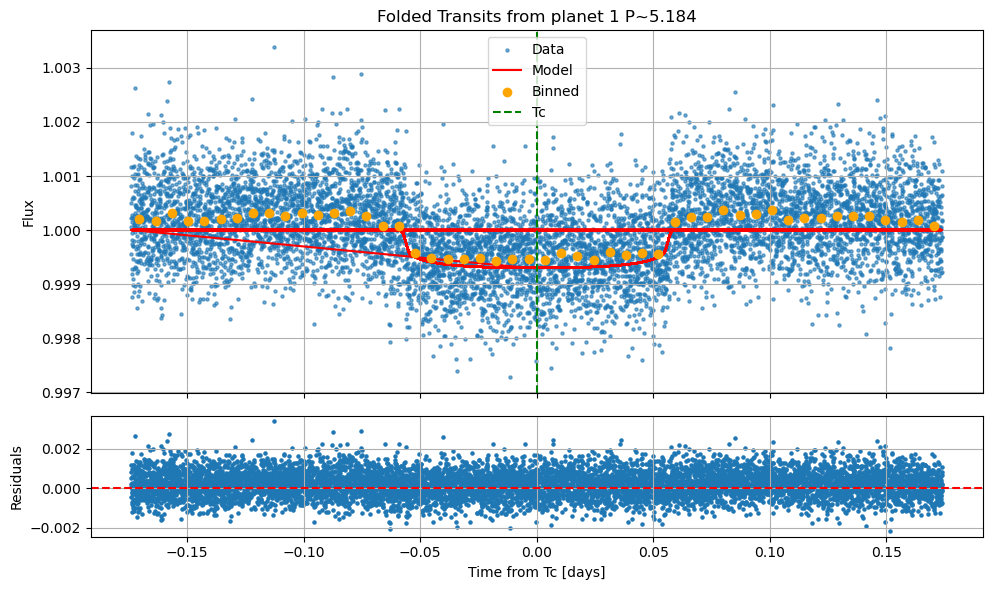

In [102]:
plot_folded_from_transits(transit_times_1, time, flux, per_1, rp_1, b_1, T14_1, u1, u2, buffer=buffer,
                         title=f'Folded Transits from planet 1 P~{round(planet_1_period.value, 3)}')

## Planet 2

In [103]:
### Planet params (from barros et al 2022)

per_2= 2.5693728
rp_2= (2.18392*u.R_earth.value) / (1.34*u.R_sun.value)
b_2=  0.4
T14_2= 2.471* 0.0416667  # convert to days from hours 


In [104]:
tc_guess_2 = transit_times_2
### get tc ranges for fit
tc_2 = []
for i in range(len(tc_guess_2)):
    start = tc_guess_2[i] - ttv_hour
    end = tc_guess_2[i] + ttv_hour
    t = np.linspace(start,end, 1000)
    tc_2.append(t)

In [105]:
### initialize arrays
tc_chi = np.zeros(len(tc_2))
tc_chi_parabola = np.zeros(len(tc_2))
ttv = np.zeros(len(tc_2))
ttv_p = np.zeros(len(tc_2))
errors = []
errors_p = []

In [106]:
tc_chi_2, ttv_2 = plot_chi_sq(time, flux, flux_err, tc_2, tc_guess_2, per_2, rp_2, b_2, T14_2, u1, u2)

In [107]:
print(tc_chi_2)

[1685.78432382 1688.32350746 1696.02767062 1698.59847015 1701.17721367
 1703.73865907 2392.32957151 2394.88337027 2397.45518586 2400.00964891
 2402.58112754 2407.73005919 2410.30618224 2412.8672885  2415.43339779
 2418.01485456 2420.59701819 2423.17177561 2425.7215072  2428.30760685
 2430.87034839 2435.996469   2438.59088277 2441.15192878 2443.7213695
 2446.30643797 2744.3089041  2746.88274582 2752.03543488 2754.58491823
 2757.15808763 2759.72422973 2764.87591966 2767.45707463 2770.024551
 2772.56931111 2775.12841832 2777.72189203 2780.28867093 2785.42520628
 2788.03400055 2790.55070172 2793.12612704 2795.69760137 3481.87897379
 3484.52921544 3487.07468213 3492.12357047 3494.56125486 3497.3903162
 3499.90038673 3502.41279027 3505.085687   3507.53902835 3510.20862405
 3512.60021437 3515.21535882 3517.7939867  3520.36322929 3523.08546303
 3525.65420277 3527.91563173 3530.58847102]


In [108]:
# Transit windows
buffer = 1.5 * T14_2
transit_times_2 = tc_chi_2

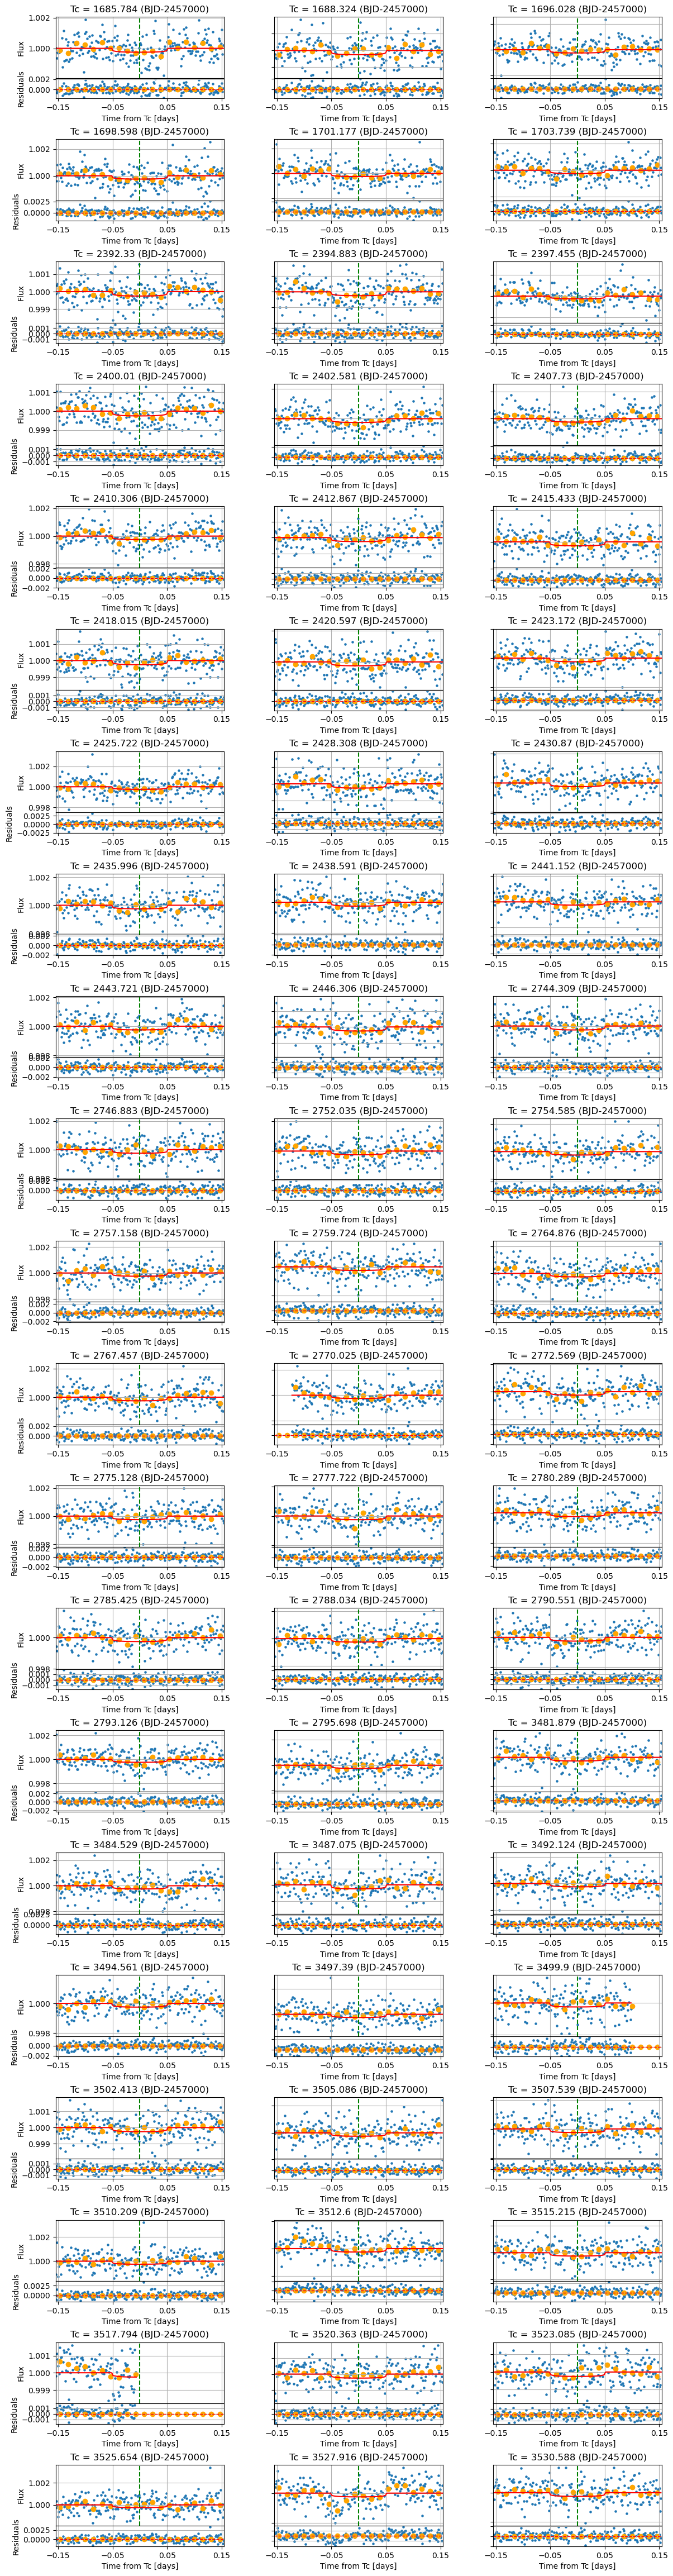

In [109]:
plot_transits(transit_times_2, per_2, rp_2, b_2, T14_2, u1, u2)

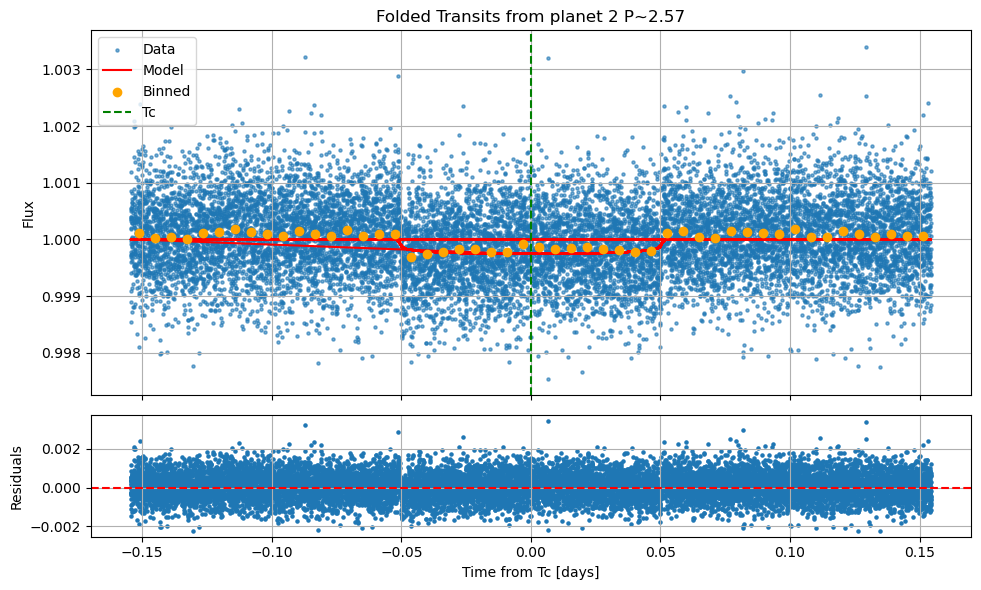

In [110]:
plot_folded_from_transits(transit_times_2, time, flux, per_2, rp_2, b_2, T14_2, u1, u2, buffer=buffer, 
                          title=f'Folded Transits from planet 2 P~{round(planet_2_period.value, 3)}')

# O-C

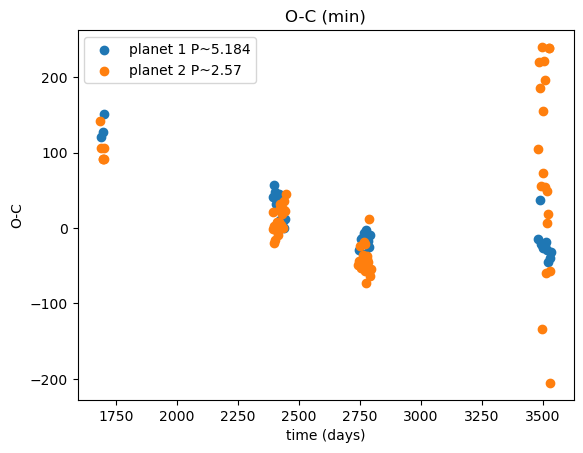

In [117]:
# TTV
# tc_chi_1 = tc_chi_2
# tc_chi_2 = tc_chi_3
# ttv_1 = ttv_2
# ttv_2 = ttv_3

plt.scatter(tc_chi_1, ttv_1*(24*60), label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2*(24*60), label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.title('O-C (min)')
plt.xlabel('time (days)')
plt.ylabel('O-C')
plt.legend()
plt.show()

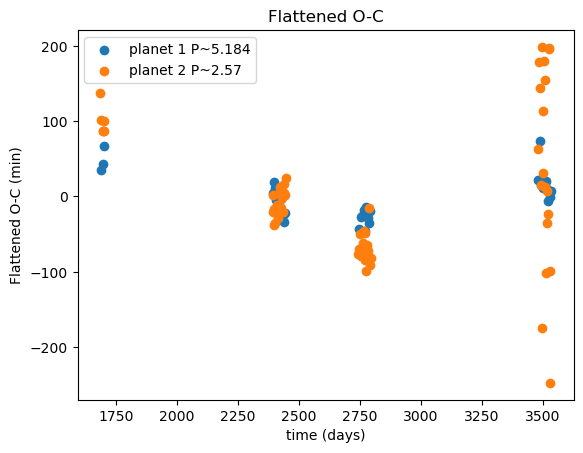

In [116]:
# Fit a linear function to the TTV data
coeffs_1 = np.polyfit(tc_chi_1, ttv_1*(24*60), 1)
linear_fit_1 = np.polyval(coeffs_1, tc_chi_1)

coeffs_2 = np.polyfit(tc_chi_2, ttv_2*(24*60), 1)
linear_fit_2 = np.polyval(coeffs_2, tc_chi_2)

# Subtract the linear fit from the TTV data
ttv_1_detrended = ttv_1*(24*60) - linear_fit_1
ttv_2_detrended = ttv_2*(24*60) - linear_fit_2

# Plot the detrended data
plt.scatter(tc_chi_1, ttv_1_detrended, label=f'planet 1 P~{round(planet_1_period.value,3)}')
plt.scatter(tc_chi_2, ttv_2_detrended, label=f'planet 2 P~{round(planet_2_period.value,3)}')
plt.title('Flattened O-C')
plt.xlabel('time (days)')
plt.ylabel('Flattened O-C (min)')
plt.legend()
plt.show()

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert to minutes
ttv_1_minutes = ttv_1 * 24 * 60

# Sine + linear model
def model(t, a, b, A, P, phi):
    return a * t + b + A * np.sin(2 * np.pi * t / P + phi)

# Initial guesses
# Guess P (period) from visual estimate (e.g., ~100 days), adjust as needed
p0 = [0, np.mean(ttv_1_minutes), 1, 100, 0]  

# Fit the model
params, _ = curve_fit(model, tc_chi_1, ttv_1_minutes, p0=p0, maxfev=10000)

# Extract fit values
a, b, A, P, phi = params

# Generate fitted curve
t_fit = np.linspace(min(tc_chi_1), max(tc_chi_1), 1000)
ttv_fit = model(t_fit, a, b, A, P, phi)

# # Plot data and fit
# plt.scatter(tc_chi_1, ttv_1_minutes, label='planet 1 data')
# plt.plot(t_fit, ttv_fit, color='red', label='fit: linear + sinusoid', linewidth=2)
# plt.title('TTV Fit: Linear + Sinusoid')
# plt.xlabel('time (days)')
# plt.ylabel('O-C (min)')
# plt.legend()
# plt.show()

# # Print parameters
# print(f"""
# Fit Parameters:
#   Slope (a)      = {a:.5f} min/day
#   Intercept (b)  = {b:.5f} min
#   Amplitude (A)  = {A:.5f} min
#   Period (P)     = {P:.2f} days
#   Phase (phi)    = {phi:.2f} rad
# """)


In [114]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Convert to minutes
ttv_2_minutes = ttv_2 * 24 * 60

# Sine + linear model
def model(t, a, b, A, P, phi):
    return a * t + b + A * np.sin(2 * np.pi * t / P + phi)

# Initial guesses
# Guess P (period) from visual estimate (e.g., ~100 days), adjust as needed
p0 = [0, np.mean(ttv_2_minutes), 1, 100, 0]  

# Fit the model
params, _ = curve_fit(model, tc_chi_2, ttv_2_minutes, p0=p0, maxfev=10000)

# Extract fit values
a, b, A, P, phi = params

# Generate fitted curve
t_fit_2 = np.linspace(min(tc_chi_2), max(tc_chi_2), 1000)
ttv_fit_2 = model(t_fit, a, b, A, P, phi)

# Plot data and fit
# plt.scatter(tc_chi_2, ttv_2_minutes, label='planet 1 data')
# plt.plot(t_fit_2, ttv_fit_2, color='red', label='fit: linear + sinusoid', linewidth=2)
# plt.title('TTV Fit: Linear + Sinusoid')
# plt.xlabel('time (days)')
# plt.ylabel('O-C (min)')
# plt.legend()
# plt.show()

# Print parameters
# print(f"""
# Fit Parameters:
#   Slope (a)      = {a:.5f} min/day
#   Intercept (b)  = {b:.5f} min
#   Amplitude (A)  = {A:.5f} min
#   Period (P)     = {P:.2f} days
#   Phase (phi)    = {phi:.2f} rad
# """)


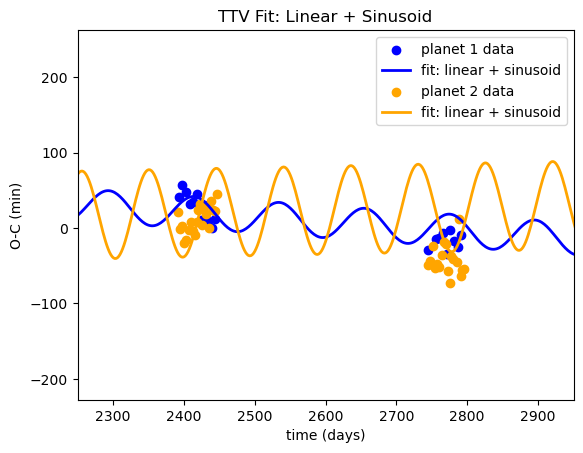

In [115]:
# Plot data and fit
plt.scatter(tc_chi_1, ttv_1_minutes, c='blue',label='planet 1 data')
plt.plot(t_fit, ttv_fit, color='blue', label='fit: linear + sinusoid', linewidth=2)

# Plot data and fit
plt.scatter(tc_chi_2, ttv_2_minutes,c='orange', label='planet 2 data')
plt.plot(t_fit_2, ttv_fit_2, color='orange', label='fit: linear + sinusoid', linewidth=2)
plt.title('TTV Fit: Linear + Sinusoid')
plt.xlabel('time (days)')
plt.ylabel('O-C (min)')
plt.xlim(2250,2950)
plt.legend()
plt.show()